# Dataset Comparison: Endless Terminals vs TMax

Compares our local `harbor_tasks_8192_deduped` dataset against AllenAI's TMax-15K and TMax-SFT-16.5K.

**Field mapping (semantically equivalent fields across schemas):**

| Ours | TMax | Meaning |
|---|---|---|
| `difficulty` | `task_complexity` | difficulty level |
| `category` | `domain` | topic area |
| `instruction.md` | `description` | task prompt |
| `solution/` files | `truth` | ground truth solution |
| `environment/Dockerfile` | `container_def` | container setup |
| `tests/test_final_state.py` | `test_final_state` | verifier |
| `environment/test_initial_state.py` | `test_initial_state` | env setup test |
| *(none)* | `skill_type`, `primitive_skills`, `scenario`, `language` | TMax-only metadata |

In [1]:
import os
import re
import glob
import tomllib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from collections import Counter
from datasets import load_dataset

TASKS_DIR = "../harbor_tasks_8192_deduped"

%matplotlib inline
plt.rcParams["figure.dpi"] = 120

/home/ec2-user/endless-terminals-playground/.venv/lib64/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load local dataset

In [2]:
def load_local_tasks(tasks_dir):
    rows = []
    task_dirs = sorted(glob.glob(os.path.join(tasks_dir, "task_*")))
    for td in task_dirs:
        task_id = os.path.basename(td)
        toml_path = os.path.join(td, "task.toml")
        instr_path = os.path.join(td, "instruction.md")
        dockerfile_path = os.path.join(td, "environment", "Dockerfile")
        init_test_path = os.path.join(td, "environment", "test_initial_state.py")
        final_test_path = os.path.join(td, "tests", "test_final_state.py")
        solution_dir = os.path.join(td, "solution")

        row = {"task_id": task_id}

        if os.path.exists(toml_path):
            with open(toml_path, "rb") as f:
                meta = tomllib.load(f)
            row["difficulty"] = meta.get("metadata", {}).get("difficulty", None)
            row["category"] = meta.get("metadata", {}).get("category", None)
            row["tags"] = meta.get("metadata", {}).get("tags", [])

        row["description"] = open(instr_path).read() if os.path.exists(instr_path) else ""
        row["description_len"] = len(row["description"])

        row["container_def"] = open(dockerfile_path).read() if os.path.exists(dockerfile_path) else ""
        row["container_def_len"] = len(row["container_def"])

        row["test_initial_state"] = open(init_test_path).read() if os.path.exists(init_test_path) else ""
        row["test_final_state"] = open(final_test_path).read() if os.path.exists(final_test_path) else ""

        # solution: join all files in solution/
        sol_files = glob.glob(os.path.join(solution_dir, "*")) if os.path.exists(solution_dir) else []
        row["truth"] = "\n".join(open(f).read() for f in sorted(sol_files) if os.path.isfile(f))

        rows.append(row)

    return pd.DataFrame(rows)


local_df = load_local_tasks(TASKS_DIR)
print(f"Local tasks loaded: {len(local_df)}")
local_df.head(2)

Local tasks loaded: 4929


,task_id,difficulty,category,tags,description,description_len,container_def,container_def_len,test_initial_state,test_final_state,truth
0,task_000000_27058e5b,medium,symbolic link management,[symbolic link management],I have a monitoring stack under /home/user/mon...,998,# syntax=docker/dockerfile:1\nFROM ubuntu:22.0...,2712,"# test_initial_state.py\n""""""\nValidates the in...","# test_final_state.py\n""""""\nValidates the fina...",
1,task_000001_31a5cdae,easy,firewall configuration,[firewall configuration],I need to open up port 9100 (node_exporter) fo...,279,# syntax=docker/dockerfile:1\nFROM ubuntu:22.0...,578,"# test_initial_state.py\n""""""\nValidates the in...","# test_final_state.py\n""""""\nValidates the fina...",


## 2. Load TMax datasets from HuggingFace

In [3]:
tmax_15k = load_dataset("allenai/TMax-15K", split="train")
tmax_sft = load_dataset("allenai/TMax-SFT-16.5K", split="train")

tmax_15k_df = tmax_15k.to_pandas()
tmax_sft_df = tmax_sft.to_pandas()

print(f"TMax-15K: {len(tmax_15k_df)} rows, columns: {tmax_15k_df.columns.tolist()}")
print(f"TMax-SFT-16.5K: {len(tmax_sft_df)} rows, columns: {tmax_sft_df.columns.tolist()}")

TMax-15K: 14601 rows, columns: ['task_id', 'domain', 'skill_type', 'primitive_skills', 'task_complexity', 'command_complexity', 'scenario', 'language', 'description', 'truth', 'test_initial_state', 'test_final_state', 'container_def']
TMax-SFT-16.5K: 2200 rows, columns: ['task_id', 'domain', 'skill_type', 'primitive_skills', 'task_complexity', 'command_complexity', 'scenario', 'language', 'description', 'truth', 'test_initial_state', 'test_final_state', 'container_def']


## 3. Dataset sizes

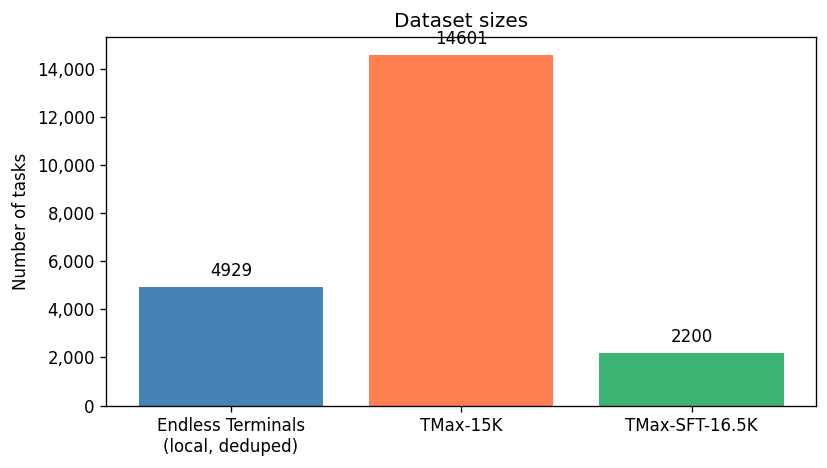

,dataset,n_tasks
0,"Endless Terminals\n(local, deduped)",4929
1,TMax-15K,14601
2,TMax-SFT-16.5K,2200


In [4]:
sizes = {
    "Endless Terminals\n(local, deduped)": len(local_df),
    "TMax-15K": len(tmax_15k_df),
    "TMax-SFT-16.5K": len(tmax_sft_df),
}

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(sizes.keys(), sizes.values(), color=["steelblue", "coral", "mediumseagreen"])
ax.bar_label(bars, fmt="%d", padding=4)
ax.set_ylabel("Number of tasks")
ax.set_title("Dataset sizes")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.show()

pd.DataFrame({"dataset": list(sizes.keys()), "n_tasks": list(sizes.values())})

## 4. Difficulty / complexity distribution (semantically aligned)

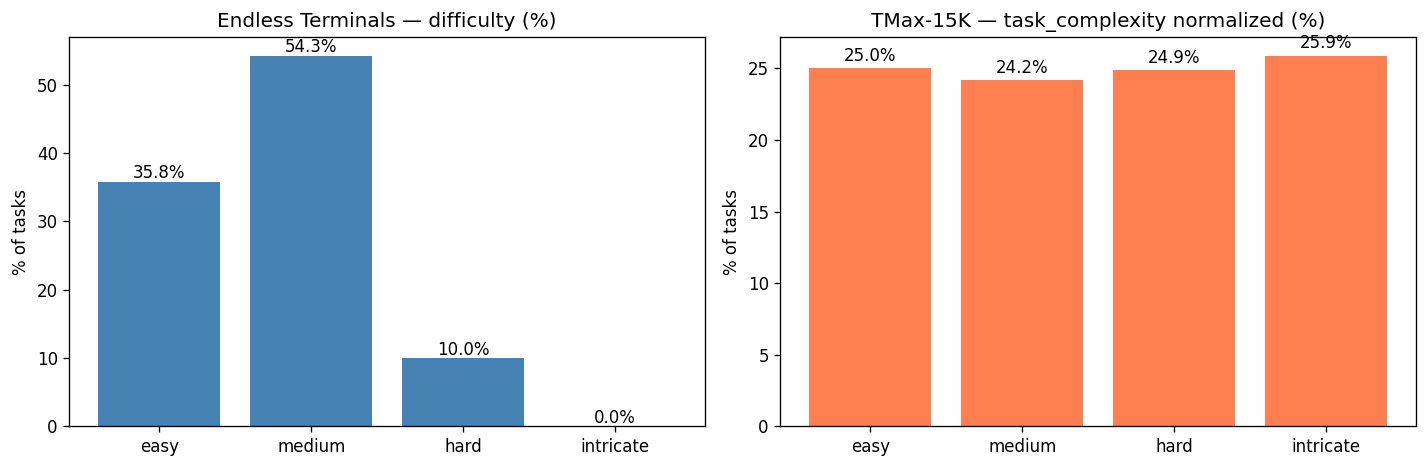

Note: TMax distributes evenly across 4 tiers (incl. 'intricate' = 30-60 commands). Ours skews easy/medium with no intricate tier.


In [5]:
# Normalize TMax's verbose task_complexity strings to easy/medium/hard/intricate buckets
def normalize_tmax_complexity(s):
    s = str(s).lower()
    if "short" in s:
        return "easy"
    elif "moderate" in s:
        return "medium"
    elif "complex" in s:
        return "hard"
    elif "intricate" in s:
        return "intricate"
    return s

tmax_15k_df["difficulty_norm"] = tmax_15k_df["task_complexity"].apply(normalize_tmax_complexity)

order = ["easy", "medium", "hard", "intricate"]
local_diff = local_df["difficulty"].value_counts().reindex(order, fill_value=0)
tmax_diff = tmax_15k_df["difficulty_norm"].value_counts().reindex(order, fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(local_diff.index, local_diff.values / len(local_df) * 100, color="steelblue")
axes[0].set_title("Endless Terminals — difficulty (%)")
axes[0].set_ylabel("% of tasks")
for i, v in enumerate(local_diff.values / len(local_df) * 100):
    axes[0].text(i, v + 0.5, f"{v:.1f}%", ha="center")

axes[1].bar(tmax_diff.index, tmax_diff.values / len(tmax_15k_df) * 100, color="coral")
axes[1].set_title("TMax-15K — task_complexity normalized (%)")
axes[1].set_ylabel("% of tasks")
for i, v in enumerate(tmax_diff.values / len(tmax_15k_df) * 100):
    axes[1].text(i, v + 0.5, f"{v:.1f}%", ha="center")

plt.tight_layout()
plt.show()

print("Note: TMax distributes evenly across 4 tiers (incl. 'intricate' = 30-60 commands). Ours skews easy/medium with no intricate tier.")

## 5. Category vs Domain (semantically aligned)

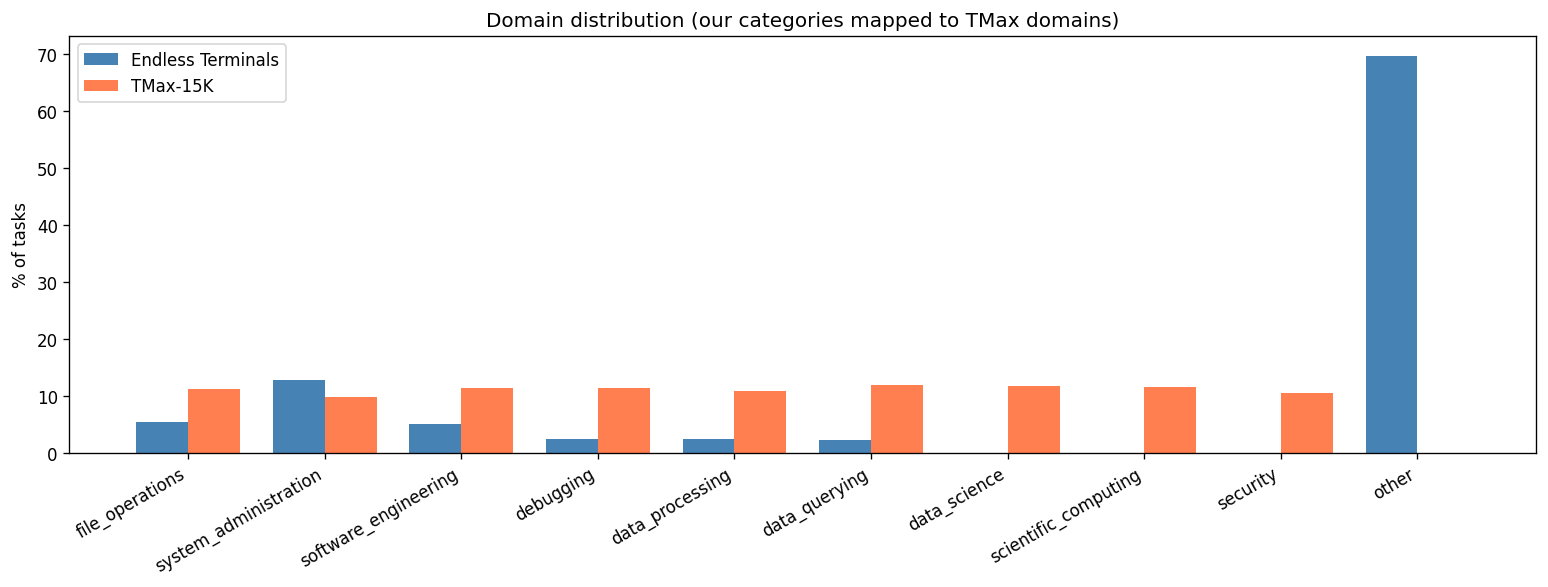

Our tasks mapped to 'other' (no domain match): 3431 (69.6%)

Top unmapped categories:
category
distributed system debugging                  110
container management                          110
exploiting/fixing security vulnerabilities    110
find and xargs batch file operations          108
environment variable and dotenv management    106
security scanning                             102
remote file synchronization                   102
Python virtual environment setup with venv    101
file compression and extraction               101
text diffing and patch application             98
user and permission management                 96
complex permissions management                 95
data transformation                            92
service configuration                          91
optimization solvers                           90


In [6]:
# Map our fine-grained categories to TMax's 9 broad domains
CATEGORY_TO_DOMAIN = {
    # file_operations
    "file and directory management": "file_operations",
    "symbolic link management": "file_operations",
    "file permissions and ownership": "file_operations",
    "archive and compression": "file_operations",
    "file search and grep": "file_operations",
    "text processing": "file_operations",
    "log parsing and analysis": "file_operations",
    # system_administration
    "dev environment setup": "system_administration",
    "running old code": "system_administration",
    "launch a webserver": "system_administration",
    "firewall configuration": "system_administration",
    "cron job management": "system_administration",
    "process management": "system_administration",
    "service management": "system_administration",
    "network configuration": "system_administration",
    "user and group management": "system_administration",
    "disk and storage management": "system_administration",
    "environment variables and shell config": "system_administration",
    "package management": "system_administration",
    "ssh configuration": "system_administration",
    "docker container management": "system_administration",
    # software_engineering
    "makefile authoring and task automation": "software_engineering",
    "semantic version bumping and changelogs": "software_engineering",
    "git operations": "software_engineering",
    "ci/cd pipeline configuration": "software_engineering",
    "api design and implementation": "software_engineering",
    "refactoring": "software_engineering",
    "testing and tdd": "software_engineering",
    "dependency management": "software_engineering",
    "build systems": "software_engineering",
    "code generation": "software_engineering",
    # debugging
    "debugging": "debugging",
    "error diagnosis and fixing": "debugging",
    "performance optimization": "debugging",
    "memory and resource profiling": "debugging",
    # data_processing
    "data pipeline with error recovery": "data_processing",
    "etl pipeline": "data_processing",
    "csv and tsv processing": "data_processing",
    "json and yaml manipulation": "data_processing",
    "xml processing": "data_processing",
    # data_querying
    "sqlite database operations via cli": "data_querying",
    "database administration": "data_querying",
    "sql query writing": "data_querying",
    # data_science
    "data analysis and visualization": "data_science",
    "machine learning pipeline": "data_science",
    "statistical analysis": "data_science",
    # scientific_computing
    "numerical computing": "scientific_computing",
    "simulation": "scientific_computing",
    # security
    "cryptography and certificates": "security",
    "security hardening": "security",
    "authentication configuration": "security",
}

def map_to_domain(cat):
    if pd.isna(cat):
        return "other"
    return CATEGORY_TO_DOMAIN.get(cat.lower().strip(), "other")

local_df["domain_mapped"] = local_df["category"].apply(map_to_domain)

tmax_domains_ordered = [
    "file_operations", "system_administration", "software_engineering",
    "debugging", "data_processing", "data_querying", "data_science",
    "scientific_computing", "security", "other"
]

local_domain_pct = local_df["domain_mapped"].value_counts().reindex(tmax_domains_ordered, fill_value=0) / len(local_df) * 100
tmax_domain_pct  = tmax_15k_df["domain"].value_counts().reindex(tmax_domains_ordered, fill_value=0) / len(tmax_15k_df) * 100

x = np.arange(len(tmax_domains_ordered))
width = 0.38

fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(x - width/2, local_domain_pct.values, width, label="Endless Terminals", color="steelblue")
ax.bar(x + width/2, tmax_domain_pct.values,  width, label="TMax-15K",          color="coral")
ax.set_xticks(x)
ax.set_xticklabels(tmax_domains_ordered, rotation=30, ha="right")
ax.set_ylabel("% of tasks")
ax.set_title("Domain distribution (our categories mapped to TMax domains)")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Our tasks mapped to 'other' (no domain match): {(local_df['domain_mapped']=='other').sum()} "
      f"({(local_df['domain_mapped']=='other').mean()*100:.1f}%)")
print("\nTop unmapped categories:")
print(local_df[local_df["domain_mapped"]=="other"]["category"].value_counts().head(15).to_string())

## 6. Skill type distribution — TMax only (no equivalent in local)

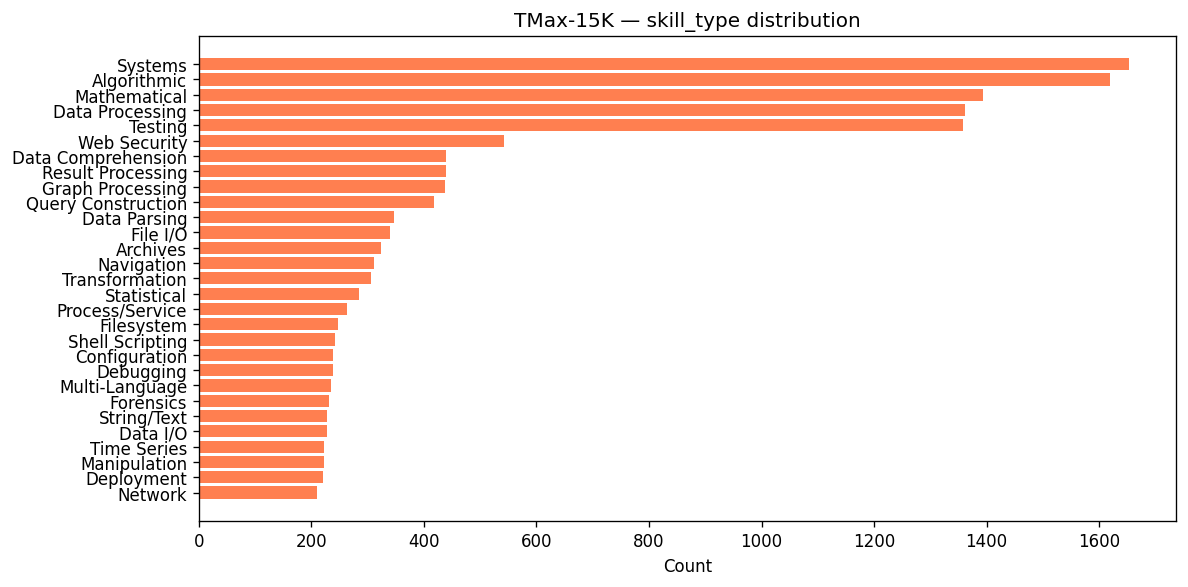

In [7]:
skill_counts = tmax_15k_df["skill_type"].value_counts()
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(skill_counts.index[::-1], skill_counts.values[::-1], color="coral")
ax.set_title("TMax-15K — skill_type distribution")
ax.set_xlabel("Count")
plt.tight_layout()
plt.show()

## 7. Description / instruction length comparison

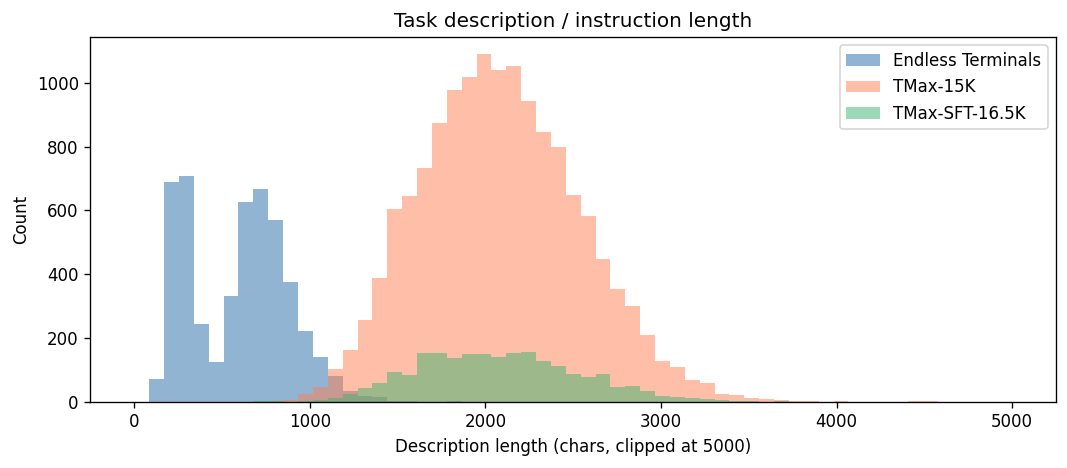

,dataset,mean_len,median_len,max_len
0,Endless Terminals,593.0,636.0,1855
1,TMax-15K,2084.0,2063.0,4503
2,TMax-SFT-16.5K,2078.0,2056.0,3674


In [8]:
tmax_15k_df["description_len"] = tmax_15k_df["description"].str.len()
tmax_sft_df["description_len"] = tmax_sft_df["description"].str.len()

fig, ax = plt.subplots(figsize=(9, 4))
bins = np.linspace(0, 5000, 60)
ax.hist(local_df["description_len"].clip(upper=5000), bins=bins, alpha=0.6, label="Endless Terminals", color="steelblue")
ax.hist(tmax_15k_df["description_len"].clip(upper=5000), bins=bins, alpha=0.5, label="TMax-15K", color="coral")
ax.hist(tmax_sft_df["description_len"].clip(upper=5000), bins=bins, alpha=0.5, label="TMax-SFT-16.5K", color="mediumseagreen")
ax.set_xlabel("Description length (chars, clipped at 5000)")
ax.set_ylabel("Count")
ax.set_title("Task description / instruction length")
ax.legend()
plt.tight_layout()
plt.show()

pd.DataFrame({
    "dataset": ["Endless Terminals", "TMax-15K", "TMax-SFT-16.5K"],
    "mean_len": [
        local_df["description_len"].mean(),
        tmax_15k_df["description_len"].mean(),
        tmax_sft_df["description_len"].mean(),
    ],
    "median_len": [
        local_df["description_len"].median(),
        tmax_15k_df["description_len"].median(),
        tmax_sft_df["description_len"].median(),
    ],
    "max_len": [
        local_df["description_len"].max(),
        tmax_15k_df["description_len"].max(),
        tmax_sft_df["description_len"].max(),
    ],
}).round(0)

## 8. Solution / truth length comparison

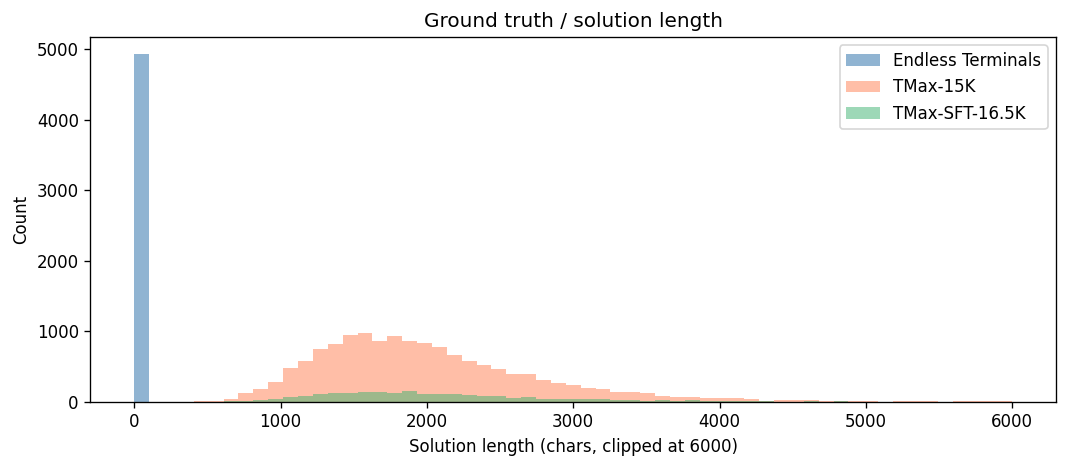

,dataset,mean_len,median_len
0,Endless Terminals,0.0,0.0
1,TMax-15K,2003.0,1873.0
2,TMax-SFT-16.5K,2053.0,1902.0


In [9]:
local_df["truth_len"] = local_df["truth"].str.len()
tmax_15k_df["truth_len"] = tmax_15k_df["truth"].str.len()
tmax_sft_df["truth_len"] = tmax_sft_df["truth"].str.len()

fig, ax = plt.subplots(figsize=(9, 4))
bins = np.linspace(0, 6000, 60)
ax.hist(local_df["truth_len"].clip(upper=6000), bins=bins, alpha=0.6, label="Endless Terminals", color="steelblue")
ax.hist(tmax_15k_df["truth_len"].clip(upper=6000), bins=bins, alpha=0.5, label="TMax-15K", color="coral")
ax.hist(tmax_sft_df["truth_len"].clip(upper=6000), bins=bins, alpha=0.5, label="TMax-SFT-16.5K", color="mediumseagreen")
ax.set_xlabel("Solution length (chars, clipped at 6000)")
ax.set_ylabel("Count")
ax.set_title("Ground truth / solution length")
ax.legend()
plt.tight_layout()
plt.show()

pd.DataFrame({
    "dataset": ["Endless Terminals", "TMax-15K", "TMax-SFT-16.5K"],
    "mean_len": [
        local_df["truth_len"].mean(),
        tmax_15k_df["truth_len"].mean(),
        tmax_sft_df["truth_len"].mean(),
    ],
    "median_len": [
        local_df["truth_len"].median(),
        tmax_15k_df["truth_len"].median(),
        tmax_sft_df["truth_len"].median(),
    ],
}).round(0)

## 9. Container definition (Dockerfile) length

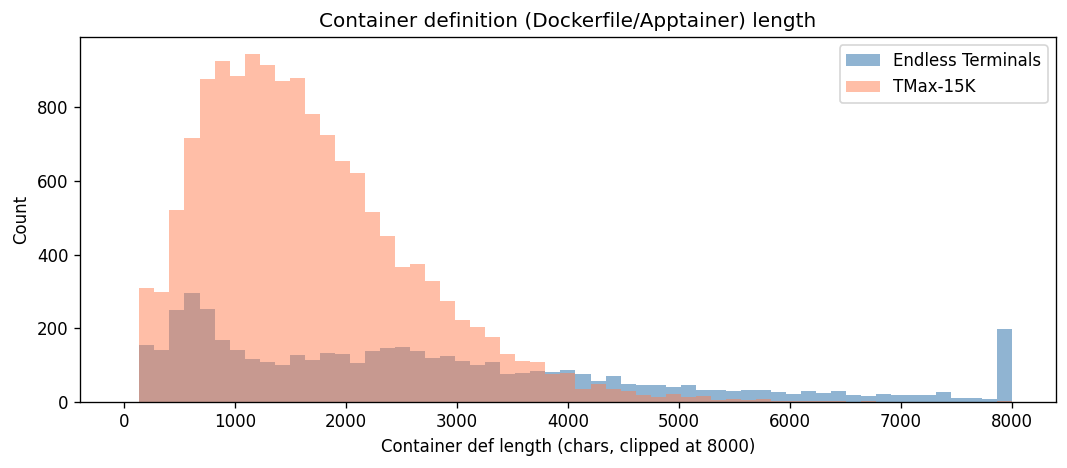

In [10]:
local_df["container_def_len"] = local_df["container_def"].str.len()
tmax_15k_df["container_def_len"] = tmax_15k_df["container_def"].str.len()

fig, ax = plt.subplots(figsize=(9, 4))
bins = np.linspace(0, 8000, 60)
ax.hist(local_df["container_def_len"].clip(upper=8000), bins=bins, alpha=0.6, label="Endless Terminals", color="steelblue")
ax.hist(tmax_15k_df["container_def_len"].clip(upper=8000), bins=bins, alpha=0.5, label="TMax-15K", color="coral")
ax.set_xlabel("Container def length (chars, clipped at 8000)")
ax.set_ylabel("Count")
ax.set_title("Container definition (Dockerfile/Apptainer) length")
ax.legend()
plt.tight_layout()
plt.show()

## 10. TMax category overlap with our local categories

In [11]:
local_cats_set = set(local_df["category"].dropna().str.lower().str.strip())
tmax_domains_set = set(tmax_15k_df["domain"].dropna().str.lower().str.strip())

overlap = local_cats_set & tmax_domains_set
only_local = local_cats_set - tmax_domains_set
only_tmax = tmax_domains_set - local_cats_set

print(f"Exact-string overlap (category vs domain): {len(overlap)}")
print(f"  Overlapping: {sorted(overlap)}")
print(f"\nLocal-only categories (top 20 by count):")
local_only_counts = local_df[local_df["category"].str.lower().str.strip().isin(only_local)]["category"].value_counts().head(20)
print(local_only_counts.to_string())
print(f"\nTMax-only domains: {sorted(only_tmax)}")

Exact-string overlap (category vs domain): 0
  Overlapping: []

Local-only categories (top 20 by count):
category
running old code                              136
file and directory management                 135
launch a webserver                            135
semantic version bumping and changelogs       134
symbolic link management                      129
performance optimization                      122
dev environment setup                         118
Makefile authoring and task automation        118
data pipeline with error recovery             117
SQLite database operations via CLI            115
distributed system debugging                  110
container management                          110
exploiting/fixing security vulnerabilities    110
find and xargs batch file operations          108
firewall configuration                        106
environment variable and dotenv management    106
security scanning                             102
remote file synchronization         

## 11. TMax-15K primitive_skills — most common

In [12]:
all_skills = [skill for skills in tmax_15k_df["primitive_skills"] for skill in (skills if isinstance(skills, list) else [])]
skill_freq = Counter(all_skills).most_common(30)

if skill_freq:
    fig, ax = plt.subplots(figsize=(10, 6))
    labels, counts = zip(*skill_freq)
    ax.barh(labels[::-1], counts[::-1], color="coral")
    ax.set_title("TMax-15K — top 30 primitive_skills")
    ax.set_xlabel("Occurrences")
    plt.tight_layout()
    plt.show()
else:
    print("primitive_skills column is empty in TMax-15K")

primitive_skills column is empty in TMax-15K


## 12. Summary table

In [13]:
summary = pd.DataFrame([
    {
        "dataset": "Endless Terminals (local)",
        "n_tasks": len(local_df),
        "n_categories": local_df["category"].nunique(),
        "has_difficulty": True,
        "has_skill_type": False,
        "has_domain": False,
        "has_solution": (local_df["truth"].str.len() > 0).sum(),
        "mean_desc_len": round(local_df["description_len"].mean()),
        "mean_solution_len": round(local_df["truth_len"].mean()),
    },
    {
        "dataset": "TMax-15K",
        "n_tasks": len(tmax_15k_df),
        "n_categories": tmax_15k_df["domain"].nunique(),
        "has_difficulty": True,
        "has_skill_type": True,
        "has_domain": True,
        "has_solution": (tmax_15k_df["truth"].str.len() > 0).sum(),
        "mean_desc_len": round(tmax_15k_df["description_len"].mean()),
        "mean_solution_len": round(tmax_15k_df["truth_len"].mean()),
    },
    {
        "dataset": "TMax-SFT-16.5K",
        "n_tasks": len(tmax_sft_df),
        "n_categories": tmax_sft_df["domain"].nunique(),
        "has_difficulty": True,
        "has_skill_type": True,
        "has_domain": True,
        "has_solution": (tmax_sft_df["truth"].str.len() > 0).sum(),
        "mean_desc_len": round(tmax_sft_df["description_len"].mean()),
        "mean_solution_len": round(tmax_sft_df["truth_len"].mean()),
    },
])

summary

,dataset,n_tasks,n_categories,has_difficulty,has_skill_type,has_domain,has_solution,mean_desc_len,mean_solution_len
0,Endless Terminals (local),4929,61,True,False,False,0,593,0
1,TMax-15K,14601,9,True,True,True,14601,2084,2003
2,TMax-SFT-16.5K,2200,9,True,True,True,2200,2078,2053
